# 🪸 Coral Bleaching Prediction — CNN + LSTM
**Model:** CNN extracts spatial features from each day's image, LSTM learns the trend over 7 days

**Input:** 7 consecutive days × (4, 224, 224) stacked images

**Output:** BAA label (0–4)

**Train:** 2018–2023 | **Test:** 2024–2025

## Step 1: Mount Google Drive

In [5]:
# ── Upload 3_dataset.zip from your laptop ──────────────────────
from google.colab import files
import zipfile, os

print("Click 'Choose Files' and select 3_dataset.zip ...")
uploaded = files.upload()  # ← button appears here

# Unzip
with zipfile.ZipFile('3_dataset.zip', 'r') as z:
    z.extractall('.')
print("Unzipped!")

# Set paths (local to Colab session)
DATASET_DIR = '/content/3_dataset'
SAVE_DIR    = '/content/4_models'
RESULTS_DIR = '/content/5_results'

os.makedirs(SAVE_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Dataset ready!')
print('Train files:', len(os.listdir(f'{DATASET_DIR}/train')))
print('Test files: ', len(os.listdir(f'{DATASET_DIR}/test')))

Click 'Choose Files' and select 3_dataset.zip ...


Saving 3_dataset.zip to 3_dataset.zip
Unzipped!
Dataset ready!
Train files: 1915
Test files:  727


## Step 2: Install & Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## Step 3: Dataset — Sequence Loader
For CNN+LSTM we load **7 consecutive days** as one sample

In [7]:
class CoralSequenceDataset(Dataset):
    """
    Loads sequences of 7 consecutive days.
    Input shape:  (7, 4, 224, 224)
    Label:        BAA value of the LAST day in sequence
    """
    def __init__(self, dataset_dir, labels_csv, seq_len=7):
        self.dataset_dir = dataset_dir
        self.seq_len     = seq_len

        # Load labels
        df = pd.read_csv(labels_csv)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)

        # Keep only dates where .npy file exists
        valid = []
        for _, row in df.iterrows():
            d    = row['date']
            path = f"{dataset_dir}/stacked_{d.year}_{d.month:02d}_{d.day:02d}.npy"
            if os.path.exists(path):
                valid.append({'date': d, 'label': int(row['label']), 'path': path})

        self.records = valid
        print(f'  Valid samples: {len(self.records)}')
        print(f'  Sequences of {seq_len} days: {len(self.records) - seq_len + 1}')

    def __len__(self):
        return len(self.records) - self.seq_len + 1

    def __getitem__(self, idx):
        # Load seq_len consecutive days
        frames = []
        for i in range(self.seq_len):
            arr = np.load(self.records[idx + i]['path'])  # (4, 224, 224)
            frames.append(arr)

        # Stack into (seq_len, 4, 224, 224)
        sequence = np.stack(frames, axis=0)
        label    = self.records[idx + self.seq_len - 1]['label']  # label of last day

        return torch.tensor(sequence, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


SEQ_LEN    = 7
BATCH_SIZE = 16

print('Loading train dataset...')
train_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/train',
    f'{DATASET_DIR}/train_labels.csv',
    seq_len=SEQ_LEN
)

print('\nLoading test dataset...')
test_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/test',
    f'{DATASET_DIR}/test_labels.csv',
    seq_len=SEQ_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Check one batch shape
x, y = next(iter(train_loader))
print(f'\nBatch input shape: {x.shape}  → (batch, seq, channels, H, W)')
print(f'Batch label shape: {y.shape}')

Loading train dataset...
  Valid samples: 1915
  Sequences of 7 days: 1909

Loading test dataset...
  Valid samples: 727
  Sequences of 7 days: 721

Train batches: 120
Test batches:  46

Batch input shape: torch.Size([16, 7, 4, 224, 224])  → (batch, seq, channels, H, W)
Batch label shape: torch.Size([16])


## Step 4: Class Weights (fix imbalance)

In [8]:
# Get all training labels
all_labels = [train_dataset.records[i + SEQ_LEN - 1]['label']
              for i in range(len(train_dataset))]

classes = np.array([0, 1, 2, 3, 4])
weights = compute_class_weight('balanced', classes=classes, y=all_labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, w in enumerate(weights):
    print(f'  Class {i}: {w:.3f}')

Class weights:
  Class 0: 0.661
  Class 1: 0.868
  Class 2: 1.720
  Class 3: 1.784
  Class 4: 0.839


## Step 5: CNN + LSTM Model

In [9]:
class CNNFeatureExtractor(nn.Module):
    """CNN to extract spatial features from one day's 4-channel image."""
    def __init__(self, in_channels=4, feature_dim=256):
        super().__init__()
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 224 → 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 112 → 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 56 → 28

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))  # → (256, 4, 4)
        )
        self.fc = nn.Linear(256 * 4 * 4, feature_dim)

    def forward(self, x):
        # x: (batch, 4, 224, 224)
        x = self.cnn(x)              # (batch, 256, 4, 4)
        x = x.view(x.size(0), -1)   # (batch, 256*4*4)
        x = self.fc(x)               # (batch, feature_dim)
        return x


class CoralCNNLSTM(nn.Module):
    """
    Full CNN + LSTM model.
    - CNN extracts features from each day
    - LSTM learns the temporal trend over 7 days
    - Final classifier predicts BAA label (0-4)
    """
    def __init__(self, feature_dim=256, hidden_dim=128, num_layers=2, num_classes=5):
        super().__init__()
        self.cnn  = CNNFeatureExtractor(in_channels=4, feature_dim=feature_dim)
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, 4, 224, 224)
        batch, seq_len, C, H, W = x.shape

        # Apply CNN to each day independently
        cnn_out = []
        for t in range(seq_len):
            feat = self.cnn(x[:, t, :, :, :])  # (batch, feature_dim)
            cnn_out.append(feat)

        # Stack into sequence: (batch, seq_len, feature_dim)
        cnn_out = torch.stack(cnn_out, dim=1)

        # Pass through LSTM
        lstm_out, _ = self.lstm(cnn_out)        # (batch, seq_len, hidden_dim)
        last_out    = lstm_out[:, -1, :]        # take last timestep

        # Classify
        out = self.classifier(last_out)         # (batch, num_classes)
        return out


model = CoralCNNLSTM(
    feature_dim=256,
    hidden_dim=128,
    num_layers=2,
    num_classes=5
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

CoralCNNLSTM(
  (cnn): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): BatchNorm2d(256, eps=1

## Step 6: Training Setup

In [10]:
EPOCHS    = 30
LR        = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Track metrics
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Training for {EPOCHS} epochs on {device}')
print(f'Train batches: {len(train_loader)} | Batch size: {BATCH_SIZE}')

Training for 30 epochs on cuda
Train batches: 120 | Batch size: 16


## Step 7: Train the Model

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  test_loader,  criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{SAVE_DIR}/cnn_lstm_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}'
          + (' ← best saved' if val_acc == best_val_acc else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/30 | Train Loss: 1.0563  Acc: 0.5982 | Val Loss: 0.8066  Acc: 0.7226 ← best saved
Epoch 02/30 | Train Loss: 0.7548  Acc: 0.7177 | Val Loss: 0.6190  Acc: 0.7393 ← best saved
Epoch 03/30 | Train Loss: 0.6986  Acc: 0.7402 | Val Loss: 0.7023  Acc: 0.7365
Epoch 04/30 | Train Loss: 0.5812  Acc: 0.7763 | Val Loss: 0.7786  Acc: 0.7420 ← best saved
Epoch 05/30 | Train Loss: 0.5665  Acc: 0.8025 | Val Loss: 0.6852  Acc: 0.7226
Epoch 06/30 | Train Loss: 0.5039  Acc: 0.8135 | Val Loss: 0.7189  Acc: 0.7559 ← best saved
Epoch 07/30 | Train Loss: 0.4797  Acc: 0.8203 | Val Loss: 0.8194  Acc: 0.7531
Epoch 08/30 | Train Loss: 0.4791  Acc: 0.8182 | Val Loss: 0.7718  Acc: 0.7545
Epoch 09/30 | Train Loss: 0.5322  Acc: 0.7962 | Val Loss: 0.5807  Acc: 0.7989 ← best saved
Epoch 10/30 | Train Loss: 0.4795  Acc: 0.8193 | Val Loss: 0.5226  Acc: 0.8169 ← best saved
Epoch 11/30 | Train Loss: 0.3971  Acc: 0.8497 | Val Loss: 0.5274  Acc: 0.8017
Epoch 12/30 | Train Loss: 0.3598  Acc: 0.8591 | Val Loss: 0.6792

## Step 8: Plot Training History

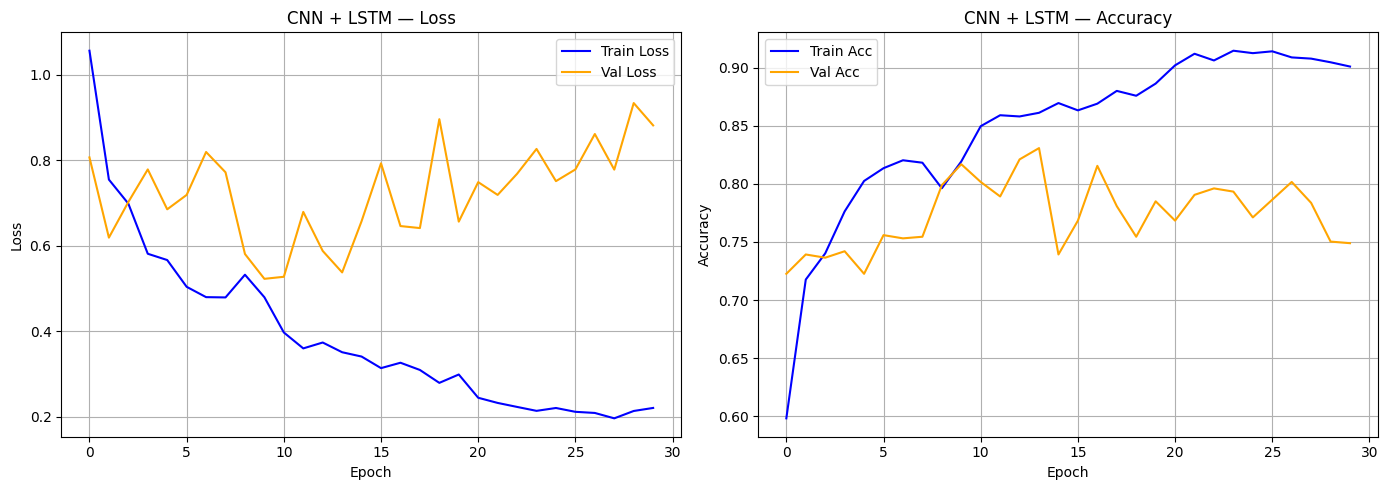

Saved training plot!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('CNN + LSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('CNN + LSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cnn_lstm_training.png', dpi=150)
plt.show()
print('Saved training plot!')

## Step 9: Evaluate on Test Set

In [13]:
# Load best model
model.load_state_dict(torch.load(f'{SAVE_DIR}/cnn_lstm_best.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out   = model(X)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')

print('='*50)
print('CNN + LSTM — TEST RESULTS')
print('='*50)
print(f'Accuracy:          {acc:.4f}')
print(f'Weighted F1 Score: {f1:.4f}')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['No Stress','Watch','Warning','Alert L1','Alert L2']
))

CNN + LSTM — TEST RESULTS
Accuracy:          0.8308
Weighted F1 Score: 0.8262

              precision    recall  f1-score   support

   No Stress       0.75      0.90      0.82       125
       Watch       0.94      0.64      0.76       237
     Warning       0.65      0.91      0.76        46
    Alert L1       0.78      0.75      0.77        53
    Alert L2       0.86      0.97      0.91       260

    accuracy                           0.83       721
   macro avg       0.80      0.84      0.80       721
weighted avg       0.85      0.83      0.83       721



## Step 10: Confusion Matrix

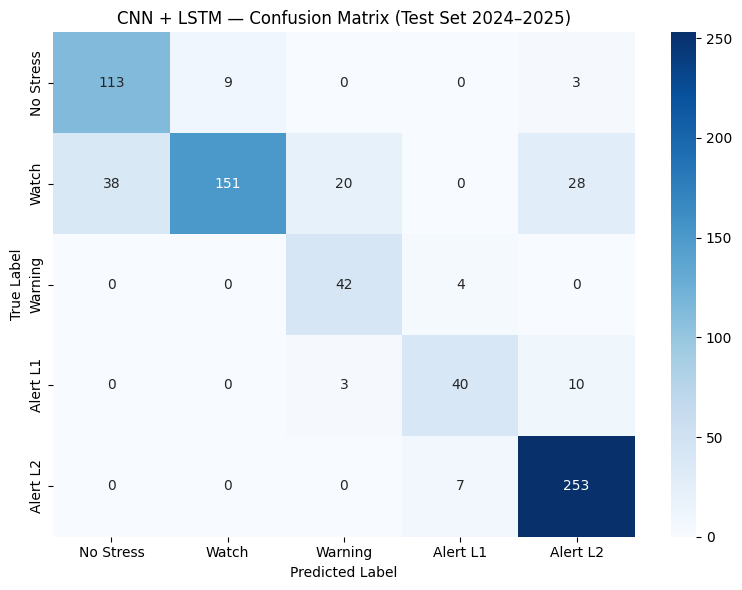

Saved confusion matrix!


In [14]:
cm     = confusion_matrix(all_labels, all_preds)
labels = ['No Stress', 'Watch', 'Warning', 'Alert L1', 'Alert L2']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title('CNN + LSTM — Confusion Matrix (Test Set 2024–2025)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cnn_lstm_confusion.png', dpi=150)
plt.show()
print('Saved confusion matrix!')

## Step 11: Save Results for Comparison

In [15]:
import json

results = {
    'model':     'CNN + LSTM',
    'accuracy':  round(float(acc), 4),
    'f1_weighted': round(float(f1), 4),
    'best_val_acc': round(float(best_val_acc), 4),
    'epochs':    EPOCHS,
    'seq_len':   SEQ_LEN,
}

with open(f'{RESULTS_DIR}/cnn_lstm_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved!')
print(json.dumps(results, indent=2))

Results saved!
{
  "model": "CNN + LSTM",
  "accuracy": 0.8308,
  "f1_weighted": 0.8262,
  "best_val_acc": 0.8308,
  "epochs": 30,
  "seq_len": 7
}


In [16]:
# ── Download all results to your laptop ────────────────────────
from google.colab import files

print("Downloading results...")
files.download(f'{SAVE_DIR}/cnn_lstm_best.pth')
files.download(f'{RESULTS_DIR}/cnn_lstm_results.json')
files.download(f'{RESULTS_DIR}/cnn_lstm_training.png')
files.download(f'{RESULTS_DIR}/cnn_lstm_confusion.png')
print("All done! Check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done! Check your Downloads folder.
